## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Structure and shape

In [2]:
test=pd.read_csv('test.csv')
train=pd.read_csv('train.csv')

In [3]:
test.shape[0]

418

In [4]:

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train.shape[0]

891

In [6]:

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


### Pre Processing

In [9]:
test.drop(columns=['PassengerId','Cabin'],inplace=True)

In [10]:
train.drop(columns=['PassengerId','Cabin'],inplace=True)

In [11]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      2
dtype: int64

In [12]:
test.isnull().sum()

Pclass       0
Name         0
Sex          0
Age         86
SibSp        0
Parch        0
Ticket       0
Fare         1
Embarked     0
dtype: int64

In [13]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [14]:
train['Embarked'] = train['Embarked'].fillna('S')

In [15]:
train['Embarked'].isnull().sum()

np.int64(0)

In [16]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
dtype: int64

In [17]:
train['Fare'] = train['Fare'].fillna(train['Fare'].mean())

In [18]:
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [19]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
dtype: int64

In [20]:
test.isnull().sum()

Pclass       0
Name         0
Sex          0
Age         86
SibSp        0
Parch        0
Ticket       0
Fare         0
Embarked     0
dtype: int64

In [21]:
train_Age=np.random.randint(train['Age'].mean()-train['Age'].std(),train['Age'].mean()+train['Age'].std(),177)

In [22]:
test_Age=np.random.randint(test['Age'].mean()-test['Age'].std(),test['Age'].mean()+test['Age'].std(),177)

In [23]:
print(train_Age)

[15 24 40 29 27 33 26 25 16 37 35 16 41 20 16 28 43 38 16 18 35 31 22 22
 41 42 37 39 34 30 21 40 39 15 17 36 17 22 38 34 42 29 39 34 21 32 36 18
 32 41 27 34 23 31 19 32 36 31 20 40 17 36 36 23 36 34 20 28 33 41 18 40
 34 25 40 16 16 35 16 26 24 35 17 26 22 33 28 28 32 16 25 25 41 41 23 36
 23 30 21 38 29 34 42 39 38 23 43 23 23 40 34 34 24 41 28 22 22 40 16 42
 20 38 33 31 41 34 26 31 30 17 33 41 32 24 25 35 38 24 20 35 24 41 21 25
 33 30 37 18 43 39 39 41 18 16 25 40 16 40 42 41 43 34 23 26 30 33 39 37
 17 24 34 33 18 26 31 36 19]


In [24]:
print(test_Age)

[38 21 41 22 19 32 35 18 22 42 31 39 42 39 30 34 17 30 25 26 34 22 19 38
 43 17 41 17 25 37 27 31 21 43 36 26 32 23 34 26 41 17 22 38 16 19 17 38
 28 26 37 30 35 37 20 33 27 24 24 28 30 42 39 23 30 39 42 18 42 26 19 18
 40 22 29 19 28 35 35 42 19 43 21 35 30 41 28 27 34 34 40 21 26 27 17 24
 23 23 27 28 40 20 37 24 29 21 23 17 29 34 24 25 26 23 20 16 37 19 31 33
 33 20 26 30 41 21 29 23 16 41 41 16 17 29 25 26 42 42 27 29 19 29 42 23
 32 31 18 19 26 21 21 25 34 40 37 24 30 17 16 30 42 30 40 27 31 37 28 33
 37 26 37 43 31 23 41 27 27]


In [25]:

train.loc[train['Age'].isnull(),'Age']=train_Age.mean()

In [26]:
test.loc[test['Age'].isnull(),'Age']=test_Age.mean()

In [27]:
train.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [28]:
test.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

## EDA

In [29]:
def Survive_ratio(train, x):
    return train[train['Pclass']==x]['Survived'].value_counts()
for i in range(1,4):
    print(Survive_ratio(train, i))

Survived
1    136
0     80
Name: count, dtype: int64
Survived
0    97
1    87
Name: count, dtype: int64
Survived
0    372
1    119
Name: count, dtype: int64


In [30]:
train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [31]:
train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [32]:
train.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

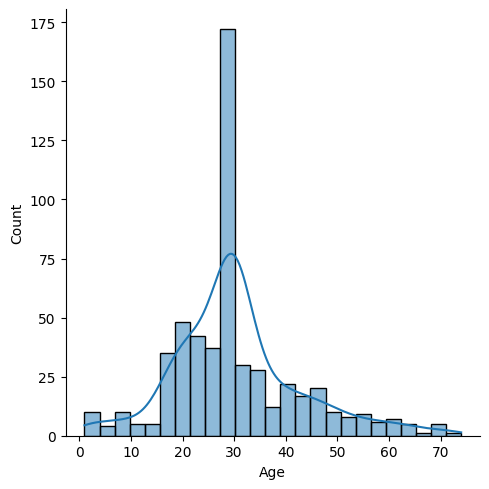

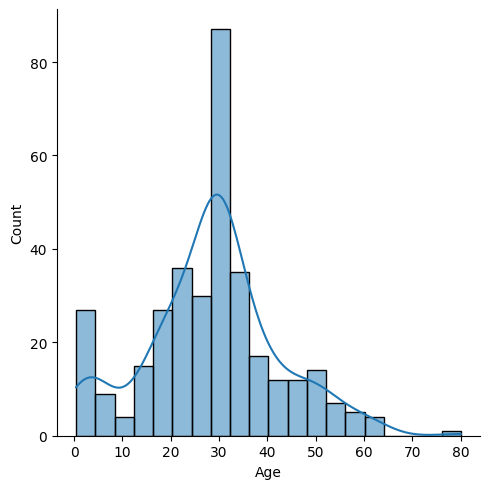

In [35]:
sns.displot(train['Age'][train['Survived']==0],kde=True)
sns.displot(train['Age'][train['Survived']==1],kde=True)

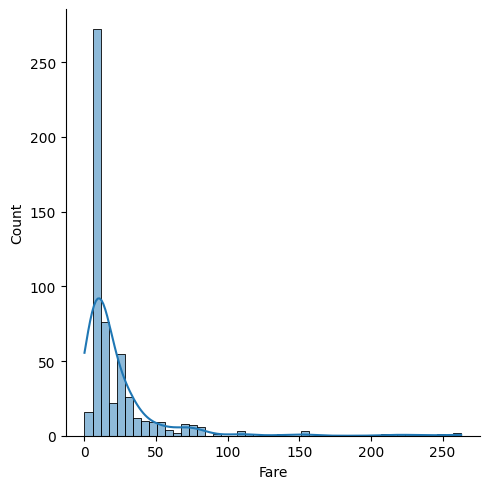

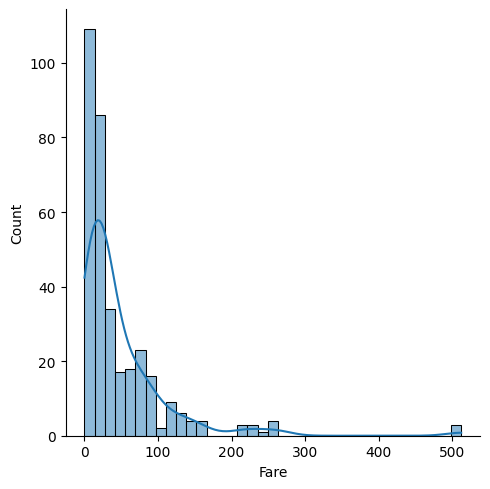

In [37]:
sns.displot(train['Fare'][train['Survived']==0],kde=True)
sns.displot(train['Fare'][train['Survived']==1],kde=True)

In [ ]:
def d aw